In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import zarr
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [ ]:
root = Path('/Volumes/data/Sasaki/MTsingleBeads')
#root = Path('/mnt/SSD/Sasaki/MTsingleBeads')

def func(root, folder):

    particles = []
    bgs = []

    for input_dir in glob.glob(str(root / folder / "*"/ "*")):
        input_dir = Path(input_dir)
        if os.path.isfile(input_dir):
            continue
        #print(input_dir)
        particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
        bg = xr.open_zarr(input_dir / "local_polar_bg.zarr")
        p_mean = particle.polar_order.mean(dim=['frame', 'particle'])
        bg_mean = bg.polar_order.mean(dim=['frame'])

        particles.append(p_mean)
        bgs.append(bg_mean)

    return particles, bgs

def make_df(particles, bgs):
    p_list = []
    bg_list = []

    i = 0
    for particle in particles:
        p_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        p_mean = np.array(particle)
        p_df['window_size'] = particles[0]['window size']
        p_df['polar_order'] = p_mean
        p_df['exp'] = i
        i += 1
        p_df = pd.DataFrame(p_df)
        p_list.append(p_df)
    i = 0
    for bg in bgs:
        bg_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        bg_mean = np.array(bg)
        bg_df['window_size'] = bgs[0]['window size']
        bg_df['polar_order'] = bg_mean
        bg_df['exp'] = i
        i += 1
        bg_df = pd.DataFrame(bg_df)
        bg_list.append(bg_df)

    p_concat = pd.concat(p_list, ignore_index=True)
    bg_concat = pd.concat(bg_list, ignore_index=True)

    return p_concat, bg_concat
def plot_polar(df, ax=None, label=None, marker='o', linestyle='-', color=None, scale = 0.11):
    if ax is None:
        ax = plt.gca()

    window_size = df['window_size'].unique() * scale
    polar_order = df.groupby('window_size').mean()['polar_order']
    sem = df.groupby('window_size').sem()['polar_order']

    ax.errorbar(window_size, polar_order, yerr=sem, label=label, marker=marker, linestyle=linestyle, color=color)

    return window_size, polar_order, sem


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_41673/434410951.py:18: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_41673/434410951.py:19: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existin

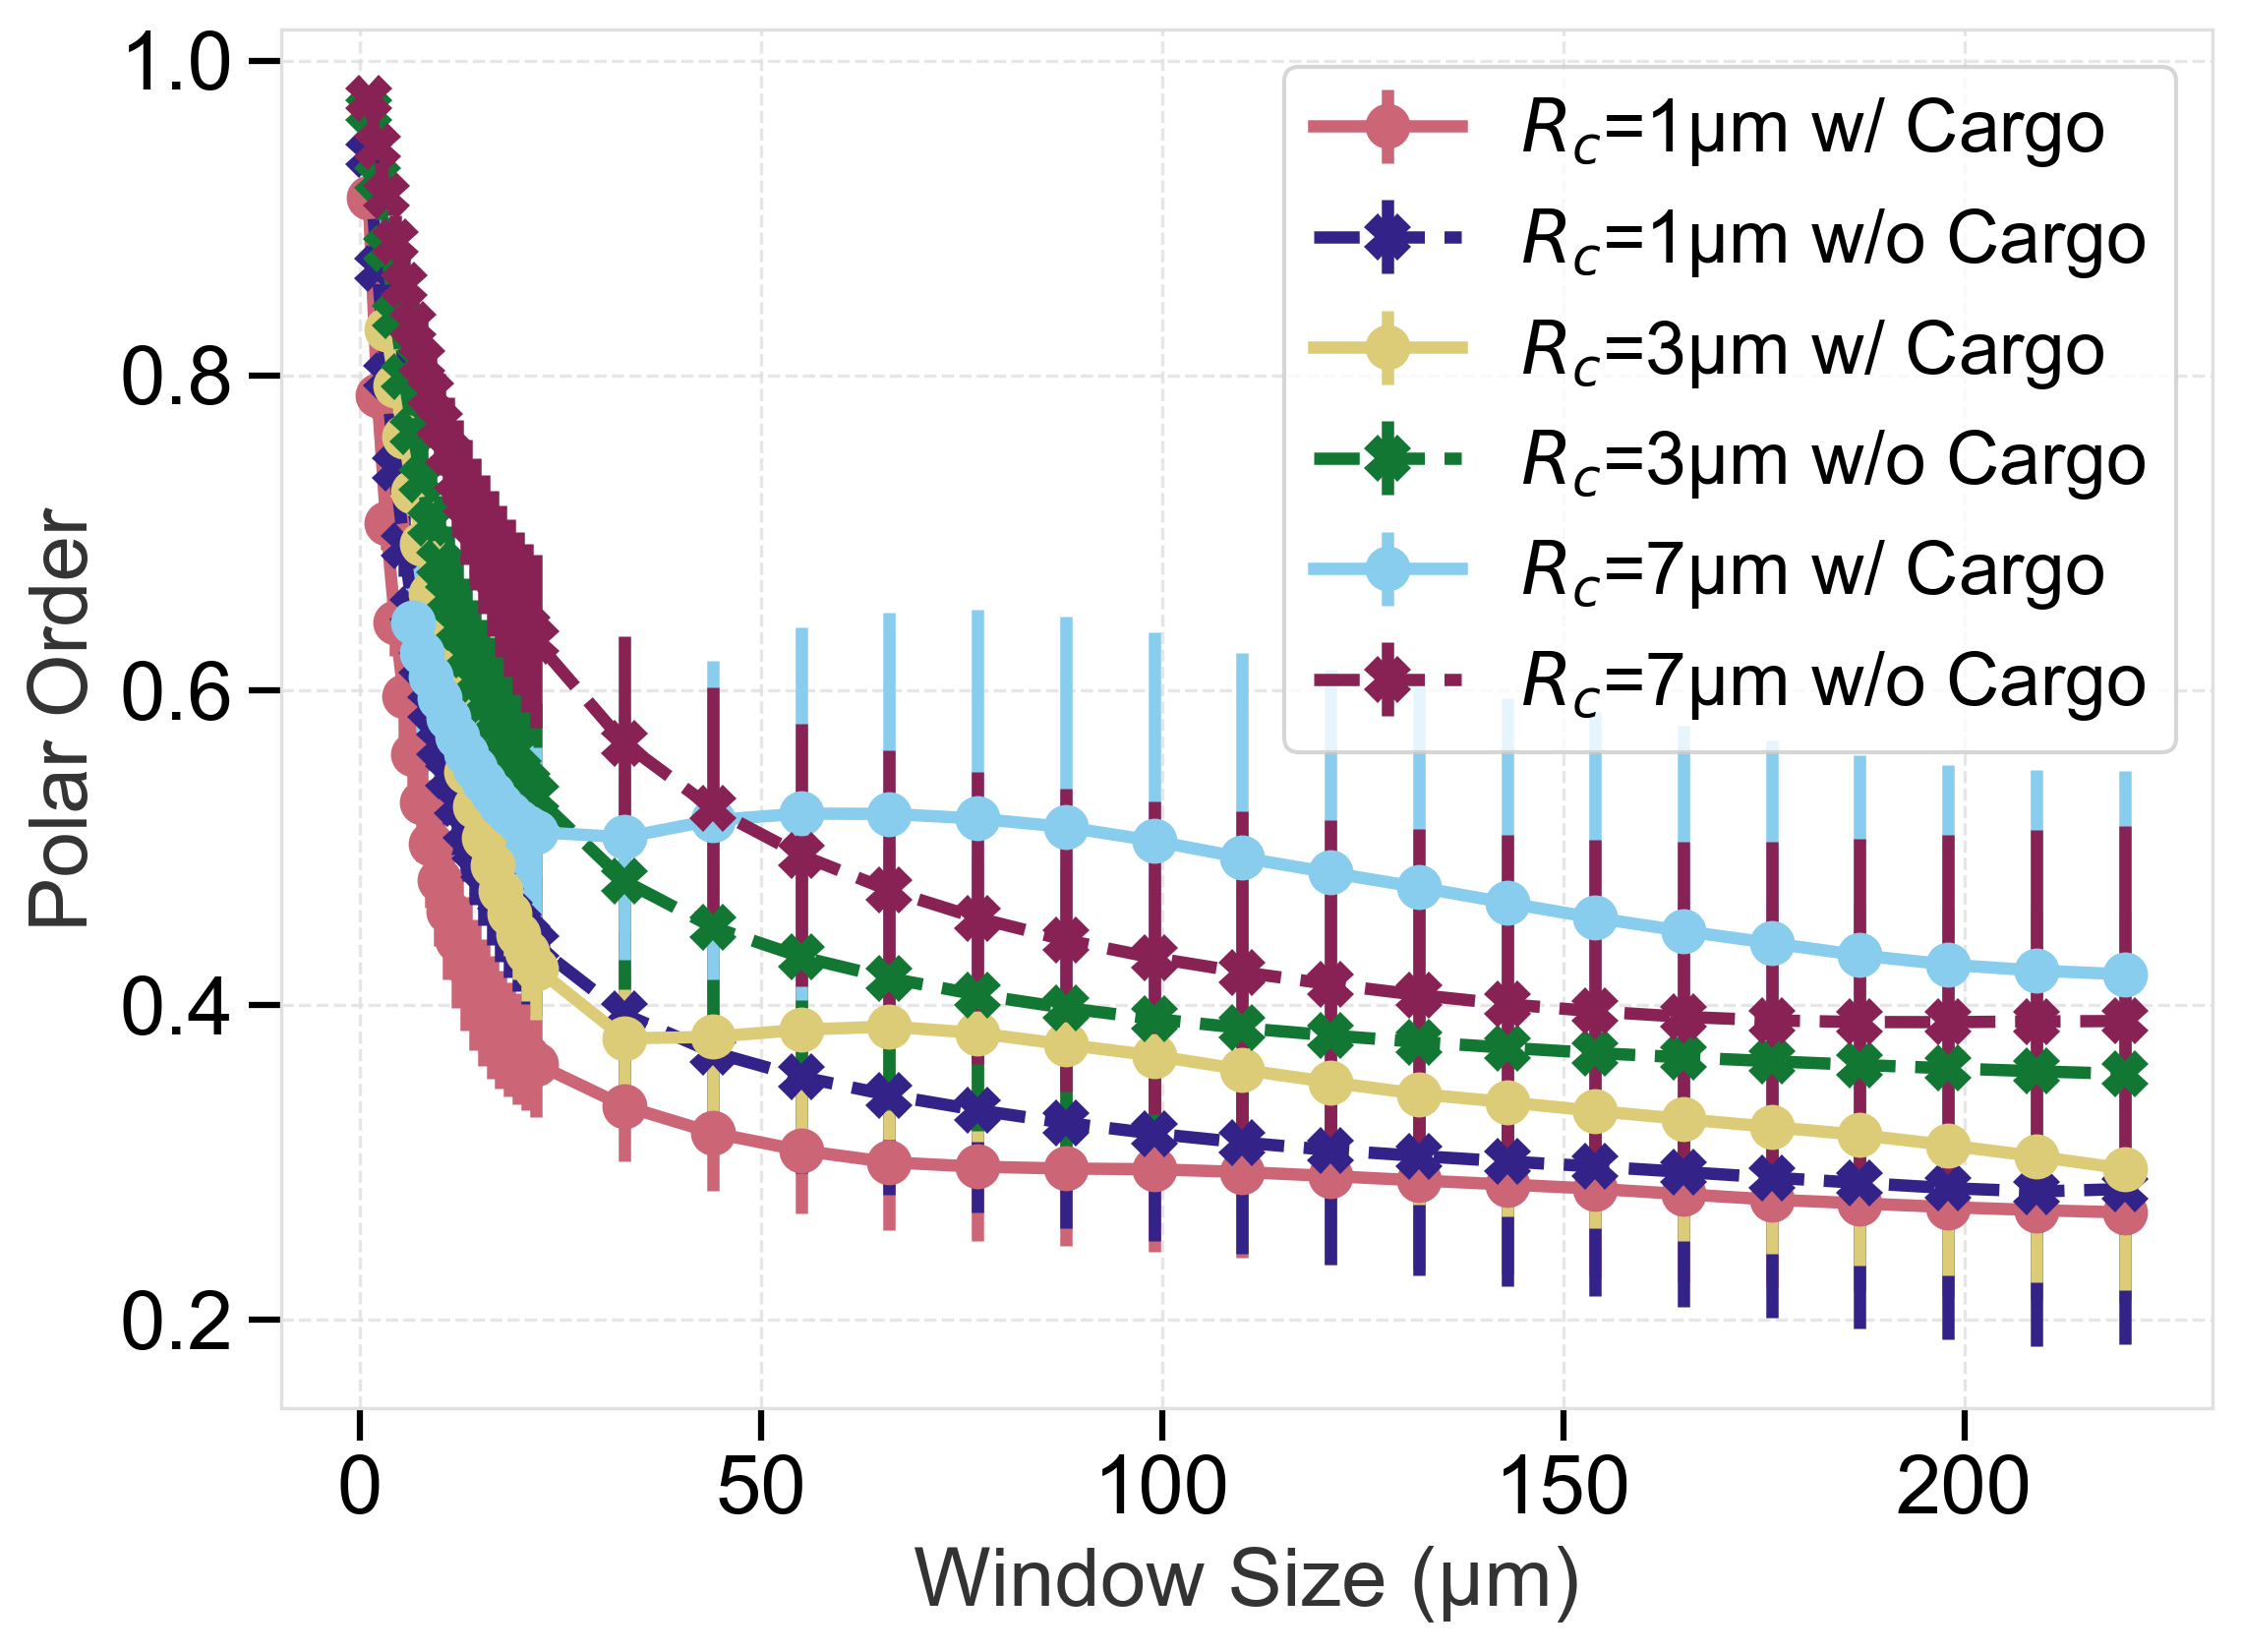

In [ ]:
particles1um, bgs1um = func(root, "beads1um")
df_p1, df_bg1 = make_df(particles1um, bgs1um)
particles3um, bgs3um = func(root, "beads3um")
df_p3, df_bg3 = make_df(particles3um, bgs3um)
particles7um, bgs7um = func(root, "beads7um")
df_p7, df_bg7 = make_df(particles7um, bgs7um)
particles8um, bgs8um = func(root, "beads8um")
df_p8, df_bg8 = make_df(particles8um, bgs8um)

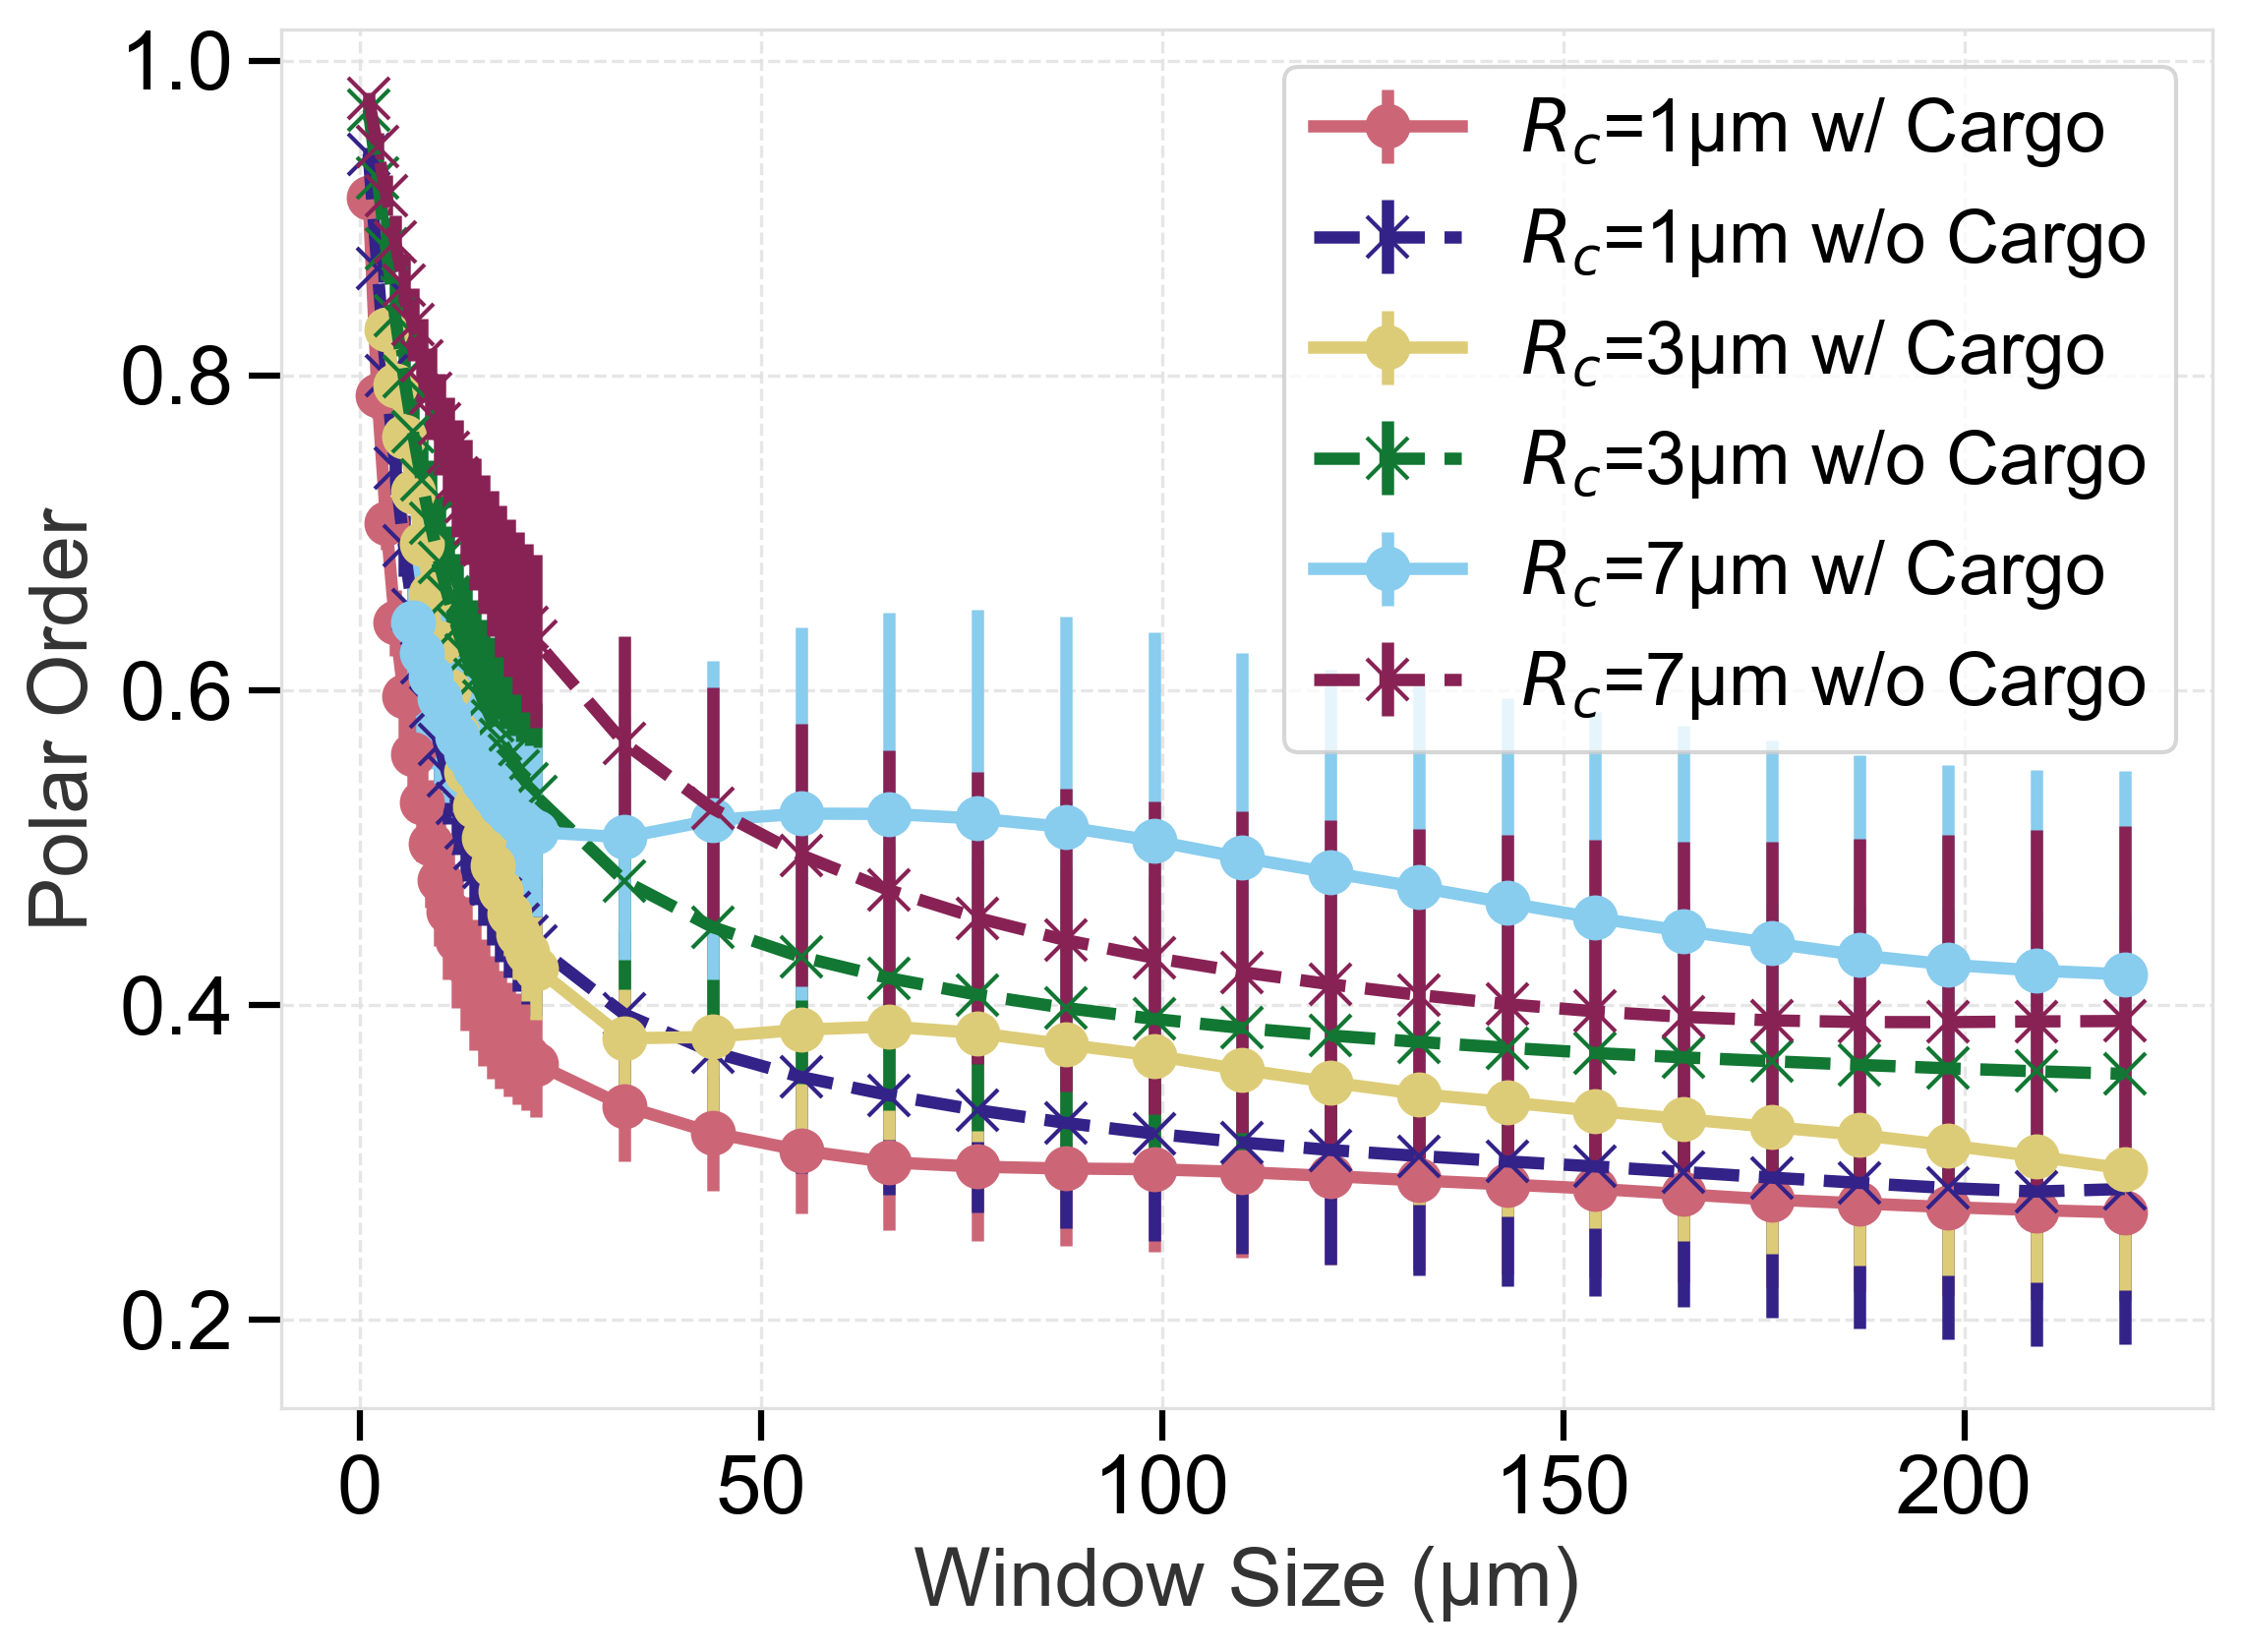

In [80]:
fig, ax = plt.subplots()
plot_polar(df_p1, ax=ax, label='$R_c$=1\u03bcm w/ Cargo', marker='o', linestyle='-')
plot_polar(df_bg1, ax=ax, label='$R_c$=1\u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p3, ax=ax, label='$R_c$=3\u03bcm w/ Cargo', marker='o', linestyle='-')
plot_polar(df_bg3, ax=ax, label='$R_c$=3\u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_p7, ax=ax, label='$R_c$=7\u03bcm w/ Cargo', marker='o', linestyle='-')
plot_polar(df_bg7, ax=ax, label='$R_c$=7\u03bcm w/o Cargo', marker='x', linestyle='--')

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar.pdf")

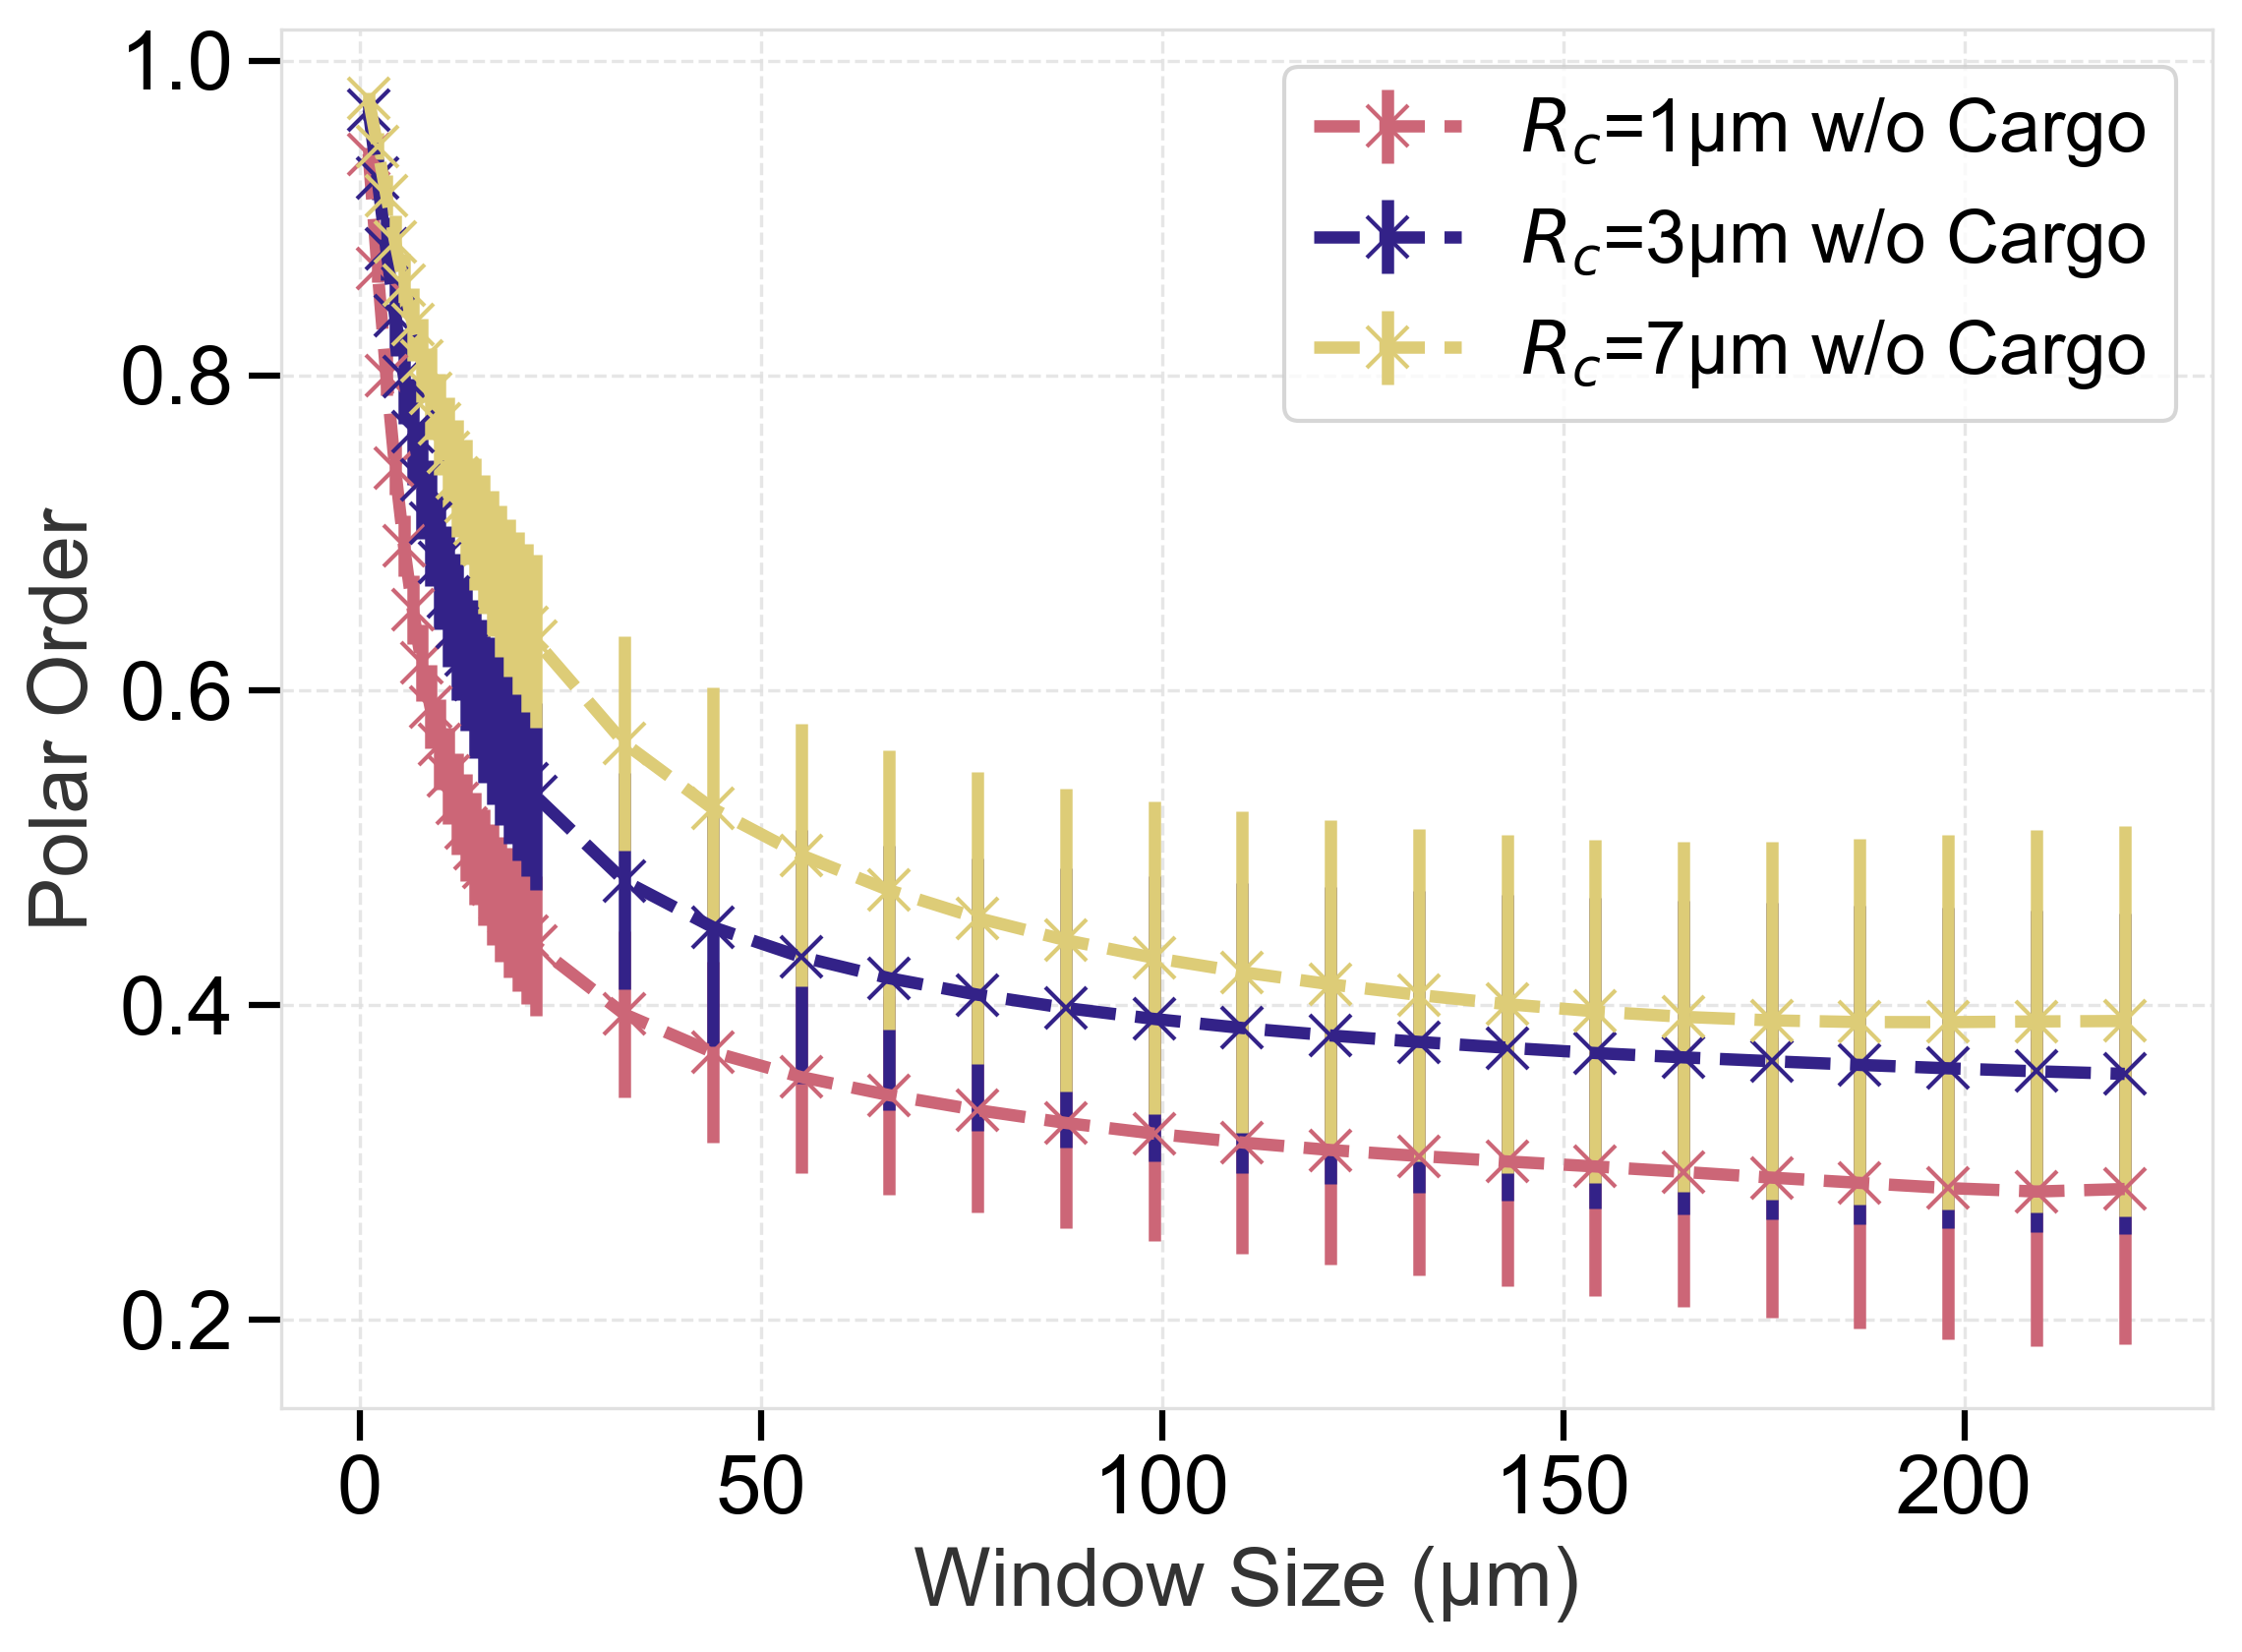

In [81]:
fig, ax = plt.subplots()
#plot_polar(df_p1, ax=ax, label='$R_c$=1\u03bcm w/ Cargo', marker='o', linestyle='-')
plot_polar(df_bg1, ax=ax, label='$R_c$=1\u03bcm w/o Cargo', marker='x', linestyle='--')
#plot_polar(df_p3, ax=ax, label='$R_c$=3\u03bcm w/ Cargo', marker='o', linestyle='-')
plot_polar(df_bg3, ax=ax, label='$R_c$=3\u03bcm w/o Cargo', marker='x', linestyle='--')

#plot_polar(df_p7, ax=ax, label='$R_c$=7\u03bcm w/ Cargo', marker='o', linestyle='-')
plot_polar(df_bg7, ax=ax, label='$R_c$=7\u03bcm w/o Cargo', marker='x', linestyle='--')

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
#ax.set_title('Polar Order vs Window Size')
ax.legend()

#fig.savefig(root / "figure" / "local_polar.pdf")